Objetivo:
Quantificar, em imagens de microscopia, o número de células positivas para a transformação pelo plasmídeo de expressão da proteína de P. vivax;

In [ ]:
pip install util-gfsilveira

In [ ]:
import os #organizador de pasta
import numpy as np #estruturação dos dados
import matplotlib.pyplot as plt #plot gráfico
import seaborn as sns #plot gráfico
from PIL import Image #visualização de img
import pandas as pd #estruturação dos dados
from util import meus_uteis, timeProcess
import joblib #convertendo imagens em valores numéricos .gz
from util import meus_uteis, timeProcess, mask_corr_graphic, printLis

Foram criadas 3 pastas a partir das imagens originais. Uma das pastas recebeu as imagens sem marcador, outra pasta recebeu as imagens marcadas sem rótulo e a terceira pasta recebeu as imagens marcadas com os rótulos. Nesse notebook, estamos trabalhando com 39 (iniciais) imagens não marcadas com os rótulos.

In [3]:
novas_imagens = '/content/drive/MyDrive/teste/imagens_julia_quantificacao/fluorescencia sem rotulo' #diretório
img_key = 0 #Chave da primeira imagem

lista_novas_img = os.listdir(novas_imagens) #listando as figuras salvas no diretório
len(lista_novas_img) #quantidade de imagens
#lista_novas_img

40

Visualização das imagens (x): Melhor resolução 300x300

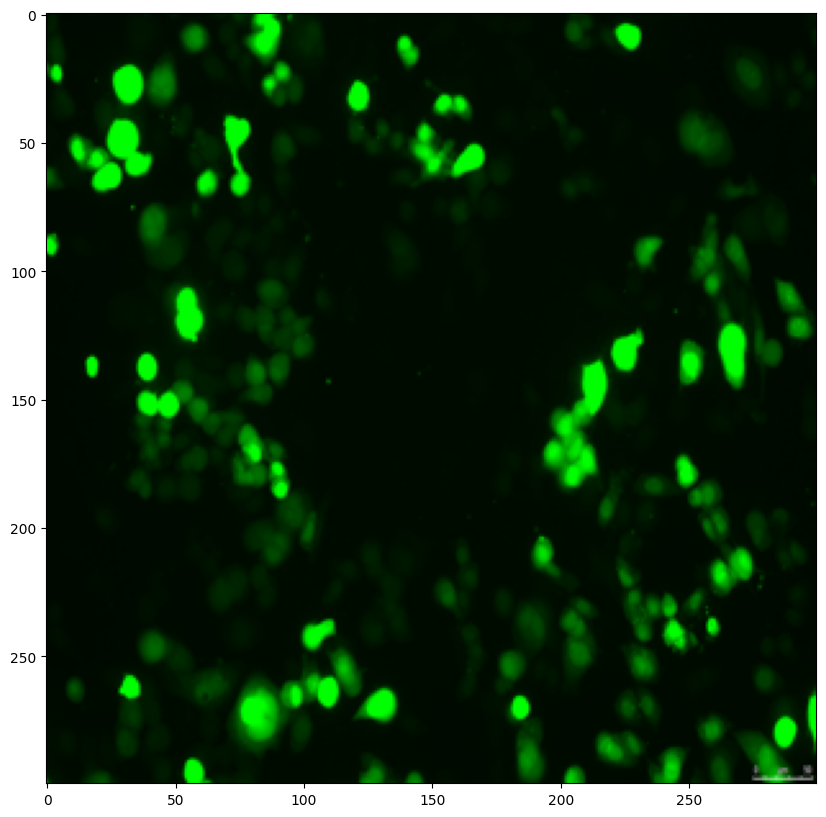

In [4]:
#testando as imagens
resize_img = (300,300) #tamanho da imagem
image_test = novas_imagens +'/'+ lista_novas_img[img_key] #chamando a primeira imagem
img = Image.open(image_test) #abrinado a primeira imagem
img = img.resize(resize_img) #formatando o tamanho

#visualização da imagem
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

Label = y (39)
Os rótulos devem acompanhar o numero de imagens, ou seja, 40 imagens, 40 rótulos que correspondam o numero de células marcadas nas imagens.

#1. Original orientation of the image.

In [5]:
y_rotulo_imagem = [n.split('rot')[1] for n in lista_novas_img] #cortando informações da imagem
y_rotulo_imagem = [(n.split('.tif')[0]) for n in y_rotulo_imagem]
y_rotulo_imagem = y_rotulo_imagem
print(len(y_rotulo_imagem)) #verificando o numero de rótulos corresponde o numero de imagens
print(y_rotulo_imagem)

40
['165', '208', '187', '227', '203', '201', '202', '123', '130', '144', '155', '129', '173', '43', '74', '60', '124', '58', '126', '76', '69', '63', '45', '40', '80', '71', '36', '76', '68', '97', '100', '70', '58', '128', '166', '129', '175', '167', '163', '124']


Formatting all images that are saved in the directory into an array - 39 images

In [6]:
lista_imagens_camp_claro = [] #lista vazia onde vai ser armazenado os dados
for file in lista_novas_img[:]:  #laço pra salvar todas as imagens
    image_test = novas_imagens +'/'+ file #qual caminho
    img = Image.open(image_test) #abrir a imagem
    img = img.resize(resize_img) #formatando em 300x300
    img = np.asarray(img)[:,:,:3] #formatando em array
    lista_imagens_camp_claro.append(img)  #adicionando cada imagem
np.asarray(lista_imagens_camp_claro).shape #verificando quantas imagens foram salvas em qual tamnho e camadas

(40, 300, 300, 3)

#2. Saving inverted images from left to right

label (78 - doubled) - dobrando o numero de rótulos

In [7]:
#dobrando o numero de rótulos - mesmo que a imagem esteja invertida, ela possui mesmo rótulo
y_rotulo_soma = y_rotulo_imagem + y_rotulo_imagem
len(y_rotulo_soma)

80

In [8]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(80, 300, 300, 3)

#3. Saving inverted images from bottom to top

y = label (117 - doubled)

In [9]:
#dobrando o numero de rótulos - mesmo que a imagem esteja invertida, ela possui mesmo rótulo
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

120

In [10]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(120, 300, 300, 3)

# 4. Saving the images flipped upside down.

label (156 - doubled) - dobrando o numero de rótulos

In [11]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

160

In [12]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(160, 300, 300, 3)

Salvando em uma lista as imagens em diferentes orientações.

In [13]:
data = timeProcess()[1]
joblib.dump(np.asarray(lista_imagens_camp_claro), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_100_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_100_resized_fluorescente_cho745_2024-9-27.gz']

In [14]:
joblib.dump(np.asarray(y_rotulo_soma), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_100_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_100_resized_fluorescente_cho745_2024-9-27.gz']

#1. Cropping 75% of the image/enlarging the image bank

In [15]:
#formula para calcular os rótulos
from math import ceil

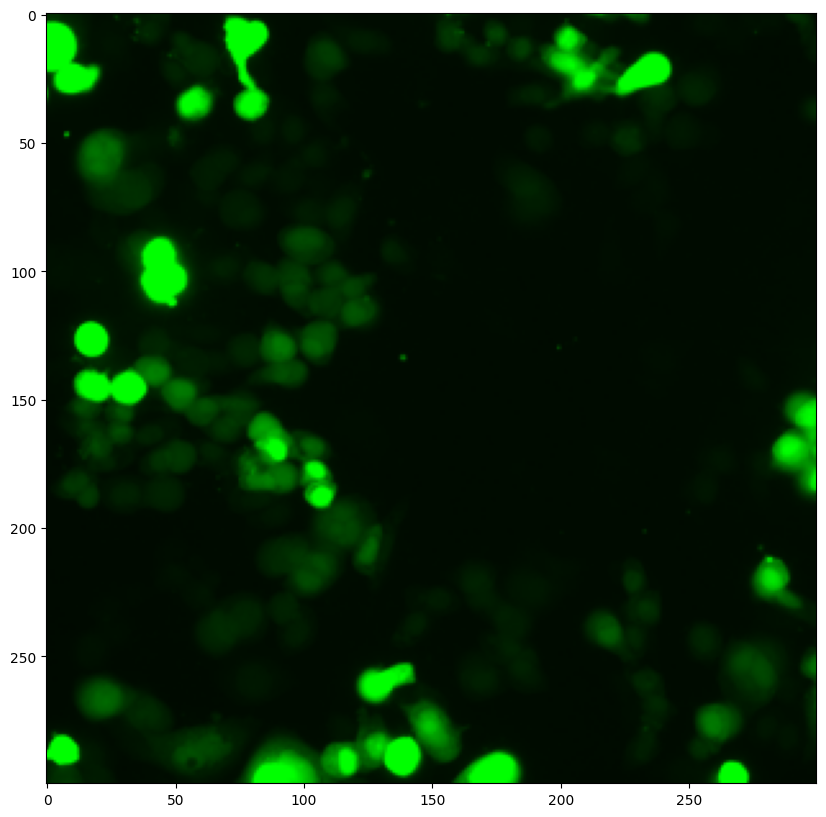

In [16]:
box = (135,135,945,945)

image_test = novas_imagens +'/'+ lista_novas_img[img_key] #chamando a primeira imagem
img = Image.open(image_test) #abrinado a primeira imagem
img = img.crop(box=box)
img = img.resize(resize_img) #formatando o tamanho

#visualização da imagem
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

label (39 - doubled)

In [17]:
y_rotulo_imagem = [n.split('rot')[1] for n in lista_novas_img]
y_rotulo_imagem = [int(n.split('.tif')[0]) for n in y_rotulo_imagem]
y_rotulo_imagem = [ceil(n-(n*0.25)) for n in y_rotulo_imagem]
len(y_rotulo_imagem)

40

In [18]:
lista_imagens_camp_claro = []
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file #qual caminho
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(40, 300, 300, 3)

#2. crop images 75% resized and rotating from left to right

label (78 - doubled) - dobrando o numero de rótulos


In [19]:
y_rotulo_soma = y_rotulo_imagem + y_rotulo_imagem
len(y_rotulo_soma)

80

In [20]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(80, 300, 300, 3)

#3. crop image 75% resized and flipping from bottom to top

label (117 - doubled) - dobrando o numero de rótulos

In [21]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

120

In [22]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(120, 300, 300, 3)

# 4. Saving crop 75% resized and flip top bottom image

label (156 - doubled) - dobrando o numero de rótulos

In [23]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

160

In [24]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(160, 300, 300, 3)

In [25]:
joblib.dump(np.asarray(lista_imagens_camp_claro), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_75_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_75_resized_fluorescente_cho745_2024-9-27.gz']

In [26]:
joblib.dump(np.asarray(y_rotulo_soma), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_75_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_75_resized_fluorescente_cho745_2024-9-27.gz']

#1. Crop 50% of the image

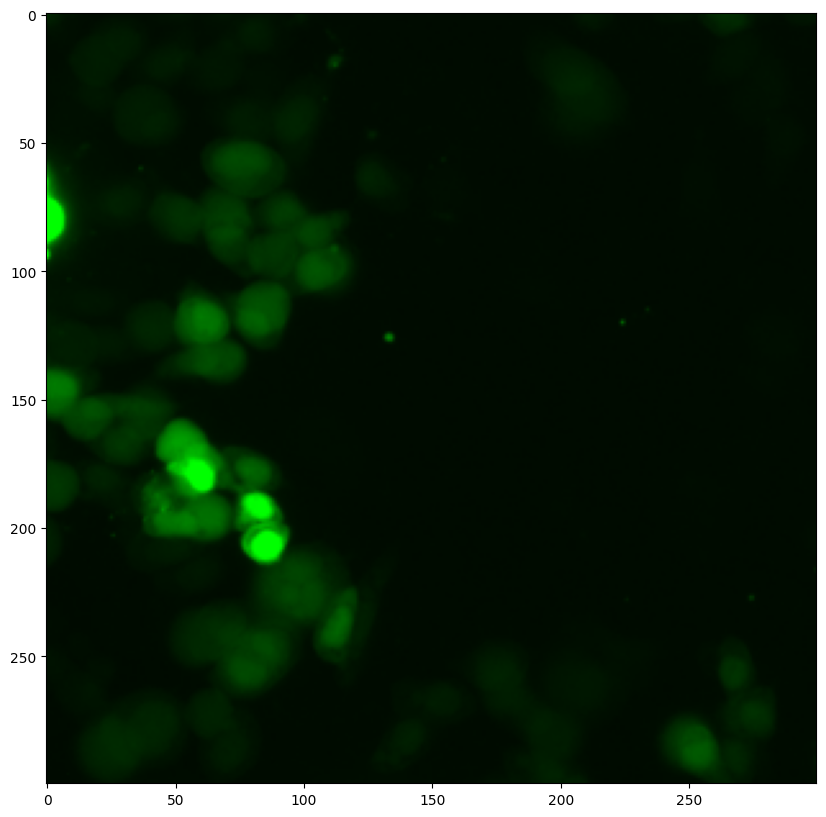

In [27]:
box = (270,270,810,810)

image_test = novas_imagens +'/'+ lista_novas_img[img_key] #chamando a primeira imagem
img = Image.open(image_test) #abrinado a primeira imagem
img = img.crop(box=box)
img = img.resize(resize_img) #formatando o tamanho

#visualização da imagem
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

label (39 - doubled)

In [28]:
y_rotulo_imagem = [n.split('rot')[1] for n in lista_novas_img]
y_rotulo_imagem = [int(n.split('.tif')[0]) for n in y_rotulo_imagem]
y_rotulo_imagem = [ceil(n/2) for n in y_rotulo_imagem]
len(y_rotulo_imagem)

40

In [29]:
lista_imagens_camp_claro = []
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file #qual caminho
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(40, 300, 300, 3)

#2. Saving crop 50% resized and turn image left right

label (78 - doubled)

In [30]:
y_rotulo_soma = y_rotulo_imagem + y_rotulo_imagem
len(y_rotulo_soma)

80

In [31]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(80, 300, 300, 3)

#3. Saving 50% resized crop and flip top bottom image

label (117 - doubled)


In [32]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

120

In [33]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(120, 300, 300, 3)

#4. Saving crop 50% resized and flip top bottom image

In [34]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

160

In [35]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(160, 300, 300, 3)

In [36]:
joblib.dump(np.asarray(lista_imagens_camp_claro), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_50_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_50_resized_fluorescente_cho745_2024-9-27.gz']

In [37]:
joblib.dump(np.asarray(y_rotulo_soma), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_50_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_50_resized_fluorescente_cho745_2024-9-27.gz']

#1. Crop 25% of the image

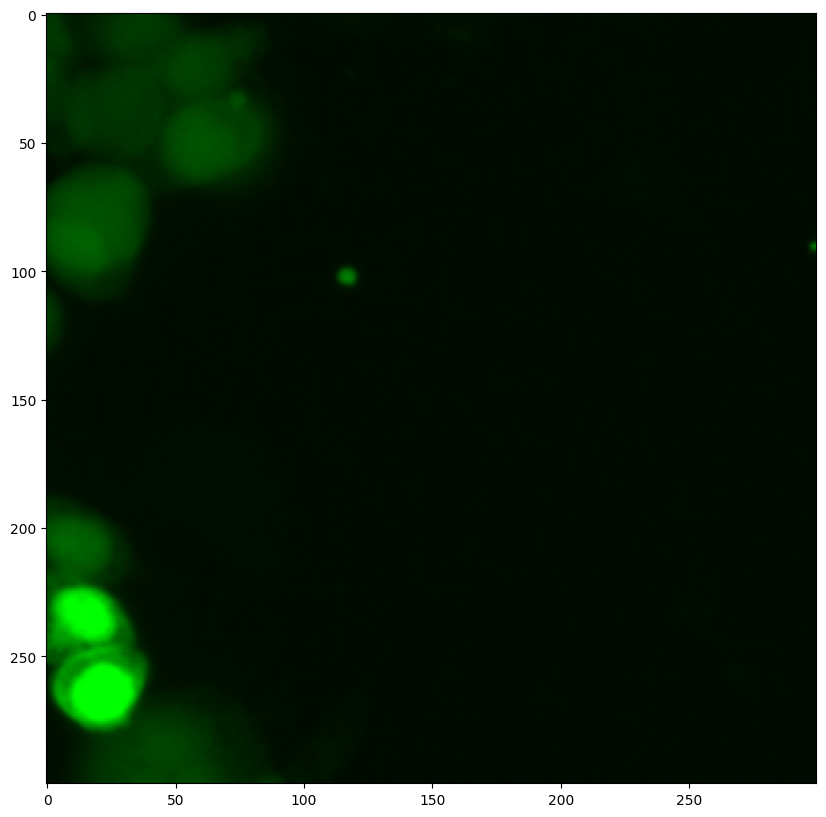

In [38]:
box = (405,405,675,675)

image_test = novas_imagens +'/'+ lista_novas_img[img_key] #chamando a primeira imagem
img = Image.open(image_test) #abrinado a primeira imagem
img = img.crop(box=box)
img = img.resize(resize_img) #formatando o tamanho

#visualização da imagem
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

label (39 - doubled)

In [39]:
y_rotulo_imagem = [n.split('rot')[1] for n in lista_novas_img]
y_rotulo_imagem = [int(n.split('.tif')[0]) for n in y_rotulo_imagem]
y_rotulo_imagem = [ceil(n-(n*0.75)) for n in y_rotulo_imagem]
len(y_rotulo_imagem)

40

In [40]:
lista_imagens_camp_claro = []
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file #qual caminho
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(40, 300, 300, 3)

#2. Saving crop 25% resized and turn image left right

label (78 - doubled)

In [41]:
y_rotulo_soma = y_rotulo_imagem + y_rotulo_imagem
len(y_rotulo_soma)

80

In [42]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(80, 300, 300, 3)

# 3. Saving crop 25% resized and flip top bottom image

label (117 - doubled)

In [43]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

120

In [44]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(120, 300, 300, 3)

#4. Saving crop 25% resized and flip top bottom image

label (156 - doubled)

In [45]:
y_rotulo_soma += y_rotulo_imagem
len(y_rotulo_soma)

160

In [46]:
for file in lista_novas_img:
    image_test = novas_imagens +'/'+ file
    img = Image.open(image_test)
    img = img.crop(box=box)
    img = img.resize(resize_img)
    img = img.transpose(Image.FLIP_TOP_BOTTOM)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = np.asarray(img)[:,:,:3]
    lista_imagens_camp_claro.append(img)
np.asarray(lista_imagens_camp_claro).shape

(160, 300, 300, 3)

In [47]:
joblib.dump(np.asarray(lista_imagens_camp_claro), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_25_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_img_25_resized_fluorescente_cho745_2024-9-27.gz']

In [48]:
joblib.dump(np.asarray(y_rotulo_soma), '/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_25_resized_fluorescente_cho745_'+data+'.gz')

['/content/drive/MyDrive/teste/imagens_julia_quantificacao/lista de imagens e rótulos - contraste digital/lista_rotulo_25_resized_fluorescente_cho745_2024-9-27.gz']